<a href="https://colab.research.google.com/github/SakshyamSingB/AI-ML/blob/main/Worksheet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


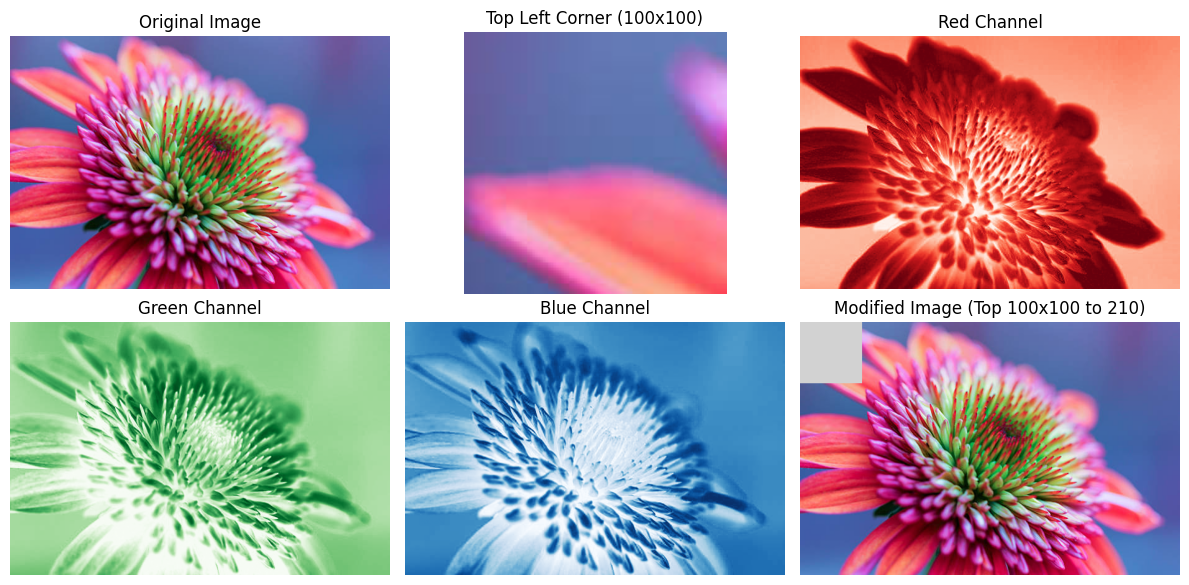

In [3]:
#1
image = Image.open("//content/drive/MyDrive/AI ML/Data/flower.jpg")
image_array = np.array(image)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")

# 2. Display top-left 100x100 pixels
top_left = image_array[0:100, 0:100]

plt.subplot(2,3,2)
plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")


# 3. Show RGB channels
red_channel = image_array[:,:,0]
green_channel = image_array[:,:,1]
blue_channel = image_array[:,:,2]

plt.subplot(2,3,3)
plt.imshow(red_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(green_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(blue_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")


# 4. Modify top-left 100x100 pixels to value 210
modified_image = image_array.copy()
modified_image[0:100,0:100] = 210

plt.subplot(2,3,6)
plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 to 210)")
plt.axis("off")

plt.tight_layout()
plt.show()

Exercise-2

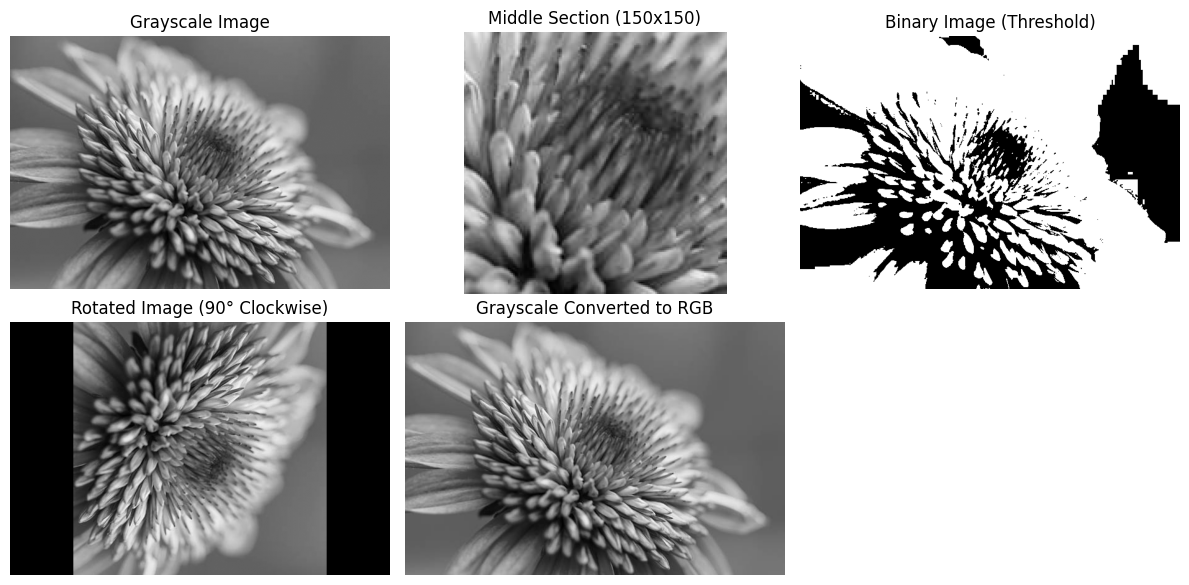

In [6]:
# Import libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and display a grayscale image
image = Image.open("/content/drive/MyDrive/AI ML/Data/flower.jpg").convert("L")   # convert image to grayscale
image_array = np.array(image)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(image_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


# 2. Extract middle 150x150 section
h, w = image_array.shape
center_h = h // 2
center_w = w // 2

middle_section = image_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.subplot(2,3,2)
plt.imshow(middle_section, cmap="gray")
plt.title("Middle Section (150x150)")
plt.axis("off")


# 3. Apply threshold (binary image)
threshold_image = image_array.copy()
threshold_image[threshold_image < 100] = 0
threshold_image[threshold_image >= 100] = 255

plt.subplot(2,3,3)
plt.imshow(threshold_image, cmap="gray")
plt.title("Binary Image (Threshold)")
plt.axis("off")


# 4. Rotate image 90° clockwise
rotated_image = image.rotate(-90)   # negative value rotates clockwise

plt.subplot(2,3,4)
plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")


# 5. Convert grayscale to RGB
rgb_image = np.stack((image_array,)*3, axis=-1)

plt.subplot(2,3,5)
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

Exercise-3

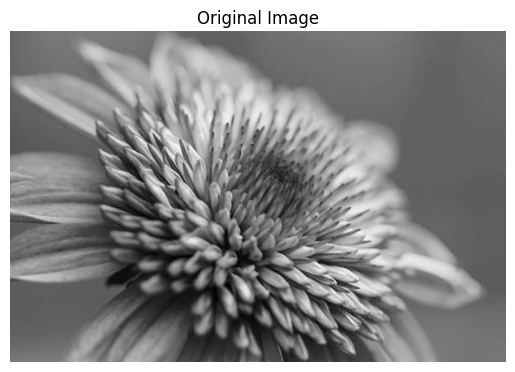

Covariance matrix shape: (612, 612)


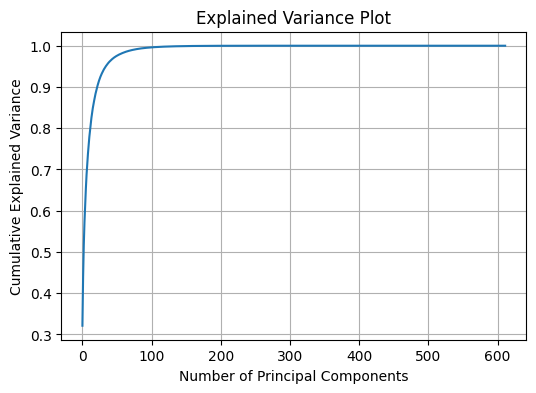

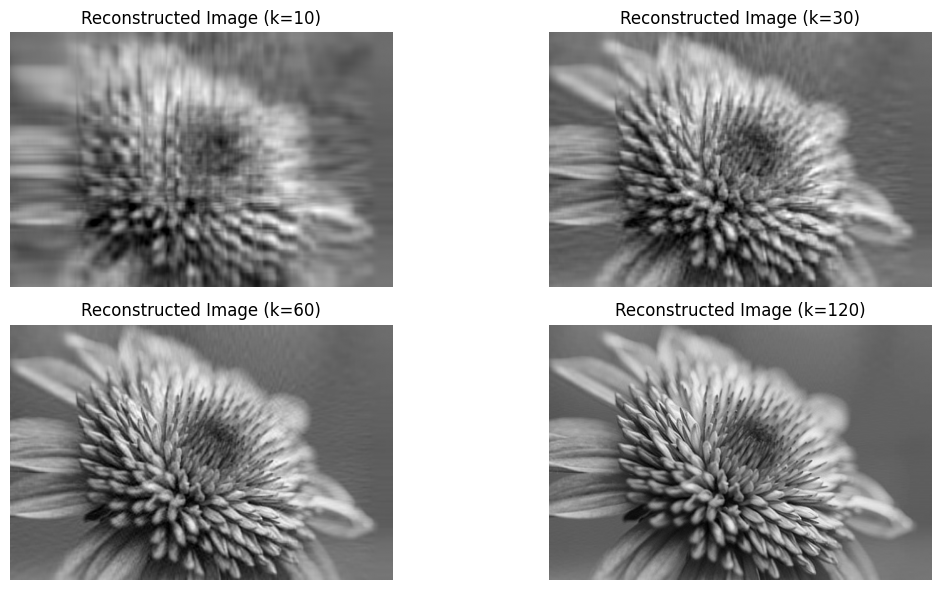

In [8]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image (grayscale)
image = Image.open("/content/drive/MyDrive/AI ML/Data/flower.jpg").convert("L")
image_array = np.array(image, dtype=float)

# Show original image
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# 1. Mean centering
mean = np.mean(image_array, axis=0)
centered_data = image_array - mean

# Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

# 2. Eigenvalues and Eigenvectors (FIXED)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# Explained variance
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid(True)
plt.show()

# 3. Reconstruction function
def reconstruct_image(k):
    pcs = sorted_eigenvectors[:, :k]

    # Project data
    compressed = np.dot(centered_data, pcs)

    # Reconstruct
    reconstructed = np.dot(compressed, pcs.T) + mean

    # Ensure real values and valid pixel range
    reconstructed = np.real(reconstructed)
    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed

# 4. Show reconstructed images
k_values = [10, 30, 60, 120]

plt.figure(figsize=(12,6))

for i, k in enumerate(k_values):
    reconstructed_img = reconstruct_image(k)

    plt.subplot(2, 2, i+1)
    plt.imshow(reconstructed_img, cmap="gray")
    plt.title(f"Reconstructed Image (k={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()